In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(
    "../data/raw/Telco-Customer-Churn.csv"
)

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [4]:
df.drop(
    columns=["customerID"],
    inplace=True
)

In [5]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [6]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [9]:
with open(
    "../models/random_forest.pkl",
    "rb"
) as file:

    rf_model = pickle.load(file)    

### Creating a SHAP Explainer

In [10]:
explainer = shap.TreeExplainer(
    rf_model
)

In [11]:
shap_values = explainer.shap_values(
    X_test
)

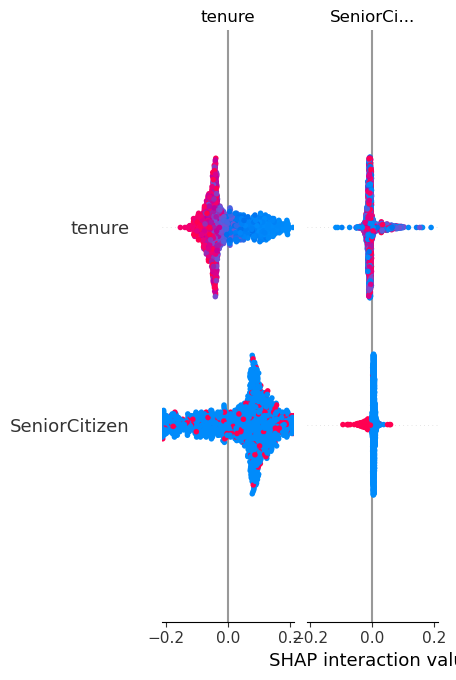

In [12]:
shap.summary_plot(
    shap_values,
    X_test
)

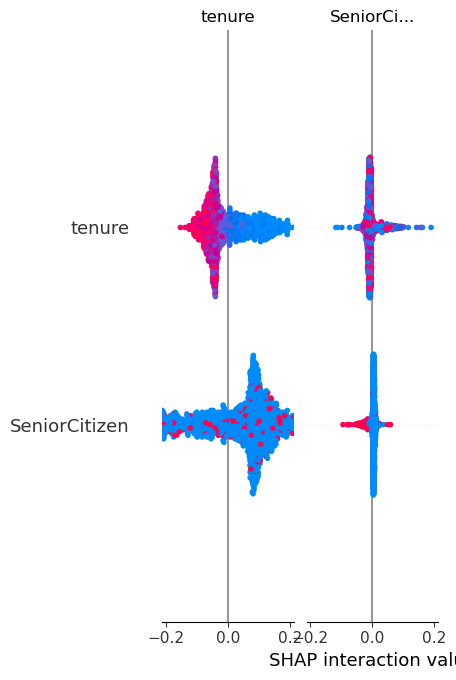

In [13]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## SHAP Findings

Contract Type, Tenure, Monthly Charges, and Total Charges are the strongest drivers of customer churn.

Customers with shorter tenure and expensive plans have significantly higher churn risk.

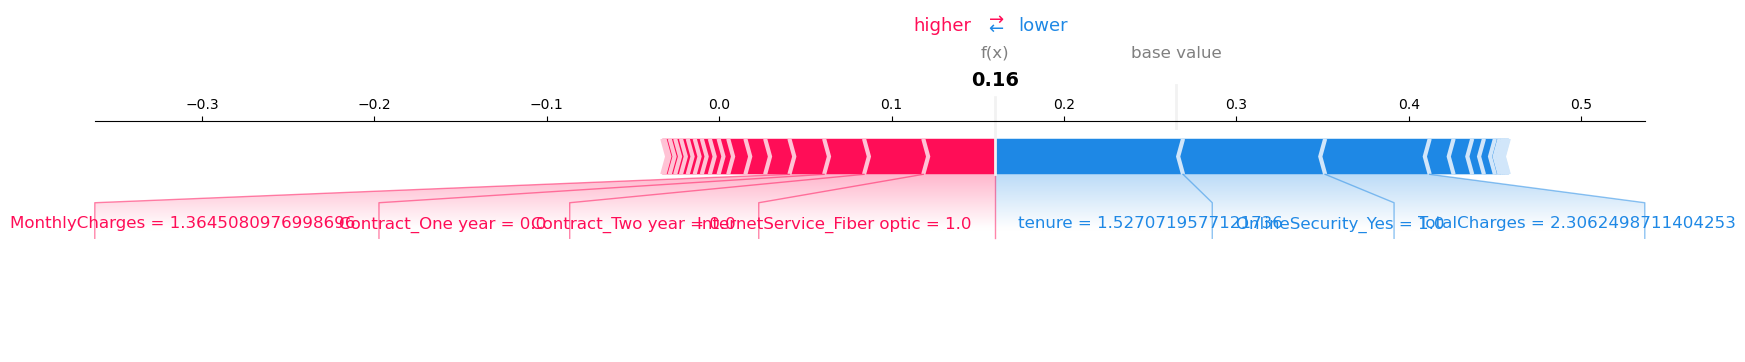

In [17]:
customer_index = 10

shap.force_plot(
    explainer.expected_value[1],
    shap_values[:, :, 1][customer_index],
    X_test.iloc[customer_index],
    matplotlib=True
)

In [18]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Importance": np.abs(shap_values[:, :, 1]).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="SHAP_Importance",
    ascending=False
)

shap_importance.head(10)

,Feature,SHAP_Importance
1,tenure,0.064277
10,InternetService_Fiber optic,0.051074
25,Contract_Two year,0.039496
3,TotalCharges,0.037781
28,PaymentMethod_Electronic check,0.031371
2,MonthlyCharges,0.022596
24,Contract_One year,0.020853
13,OnlineSecurity_Yes,0.020489
26,PaperlessBilling_Yes,0.015864
19,TechSupport_Yes,0.015036


In [19]:
explainer.expected_value[1]
shap_values[:, :, 1]

array([[-2.81656782e-03, -8.82237858e-02,  9.81210167e-03, ...,
        -7.08592182e-03, -1.69817609e-02,  3.34465112e-04],
       [ 3.11164619e-02,  1.16479177e-01,  8.40894629e-02, ...,
        -1.94889729e-02, -2.31110783e-02,  3.01136904e-03],
       [-4.89664213e-03, -3.94862158e-02,  1.01411584e-04, ...,
         3.79238080e-03, -2.27190095e-02, -3.96492417e-04],
       ...,
       [-3.17356144e-03,  3.58565090e-02, -3.40862677e-02, ...,
         1.60013220e-03, -1.83250038e-02,  4.54507719e-03],
       [-2.13855524e-03, -2.90686663e-02,  8.00304216e-03, ...,
         4.81269173e-03, -1.49617287e-02,  4.23264335e-03],
       [-5.35203712e-03, -5.73580458e-02, -1.18276090e-02, ...,
        -5.41158916e-05, -1.83508211e-02,  7.39012460e-04]])

In [21]:
shap_values_churn = shap_values[:, :, 1]

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Importance": np.abs(shap_values_churn).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="SHAP_Importance",
    ascending=False
)

shap_importance.head(10)

,Feature,SHAP_Importance
1,tenure,0.064277
10,InternetService_Fiber optic,0.051074
25,Contract_Two year,0.039496
3,TotalCharges,0.037781
28,PaymentMethod_Electronic check,0.031371
2,MonthlyCharges,0.022596
24,Contract_One year,0.020853
13,OnlineSecurity_Yes,0.020489
26,PaperlessBilling_Yes,0.015864
19,TechSupport_Yes,0.015036


In [22]:
shap_importance.to_csv(
    "../data/processed/shap_feature_importance.csv",
    index=False
)

# Explainable AI Summary

The model predictions are driven primarily by:

1. Contract Type
2. Tenure
3. Monthly Charges
4. Total Charges
5. Internet Service

SHAP provides transparent explanations that help business stakeholders understand why customers are likely to churn.